# [LDSSA Hackathon 4] – Predicting Judicial Recommendations for Clemency (NLP Specialisation)

This notebook aims to build and evaluate NLP models for predicting judicial recommendations for clemency from historical judges’ reports at the Old Bailey (1784–1827).

* Author: Jessica Rodrigues  
* Dataset preparation: Laszlo Taba  
* Date: 31-01-2026

In [341]:
import numpy as np
import pandas as pd
from pathlib import Path
pd.set_option('display.max_colwidth', None)

In [342]:
# project directory
project_dir = Path(".").resolve().parent

## 1. Task definition

The task is to predict the judicial recommendation for clemency associated with a historical criminal case. The problem is formulated as a supervised multi-class classification task, where each case is assigned one of three labels: **FAVOURABLE**, **UNFAVOURABLE**, or **NO_CLEAR_RECOMMENDATION**.

Classification is performed at the level of individual cases, without assuming links between multiple records referring to the same individual.

## 2. Data

The dataset used in this notebook is [*Judges’ Reports on Criminals convicted at the Old Bailey, 1784–1827*](https://orda.shef.ac.uk/articles/dataset/Judges_Reports_on_Criminals_convicted_at_the_Old_Bailey_1784-1827/5712118). It consists of structured summaries derived from judges’ reports and related documents concerning individuals convicted at the Old Bailey between 1784 and 1827.

The dataset was created as part of the Digital Panopticon project and is based on item-level descriptions from the Home Office series HO 47 held at The National Archives (UK). The descriptions are archival summaries rather than full transcripts of the original documents.

Each row represents an individual case. An individual may appear more than once, and no attempt is made to link multiple records referring to the same person.

For the purposes of the hackathon, the original dataset has been simplified to retain only a small number of descriptive textual fields and the target label, in order to focus the task on textual reasoning and avoid information leakage.

### Dataset columns

- `crime`: Description of the offence.  
- `initial_sentence`: Sentence passed at trial, as described.  
- `grounds_clemency`: Stated grounds cited in favour of clemency.  
- `additional_info`: Additional contextual information.  
- `doc_description`: Archivist description of the document.  
- `label`: Target variable used in this notebook.

### 2.1 Train and test sets

The dataset is split into training and test sets, stratified by the target label.

In [343]:
TRAIN_FILE = project_dir / "data" / "train.csv"
TEST_FILE = project_dir / "data" / "test.csv"

In [344]:
df_train = pd.read_csv(TRAIN_FILE, delimiter=",", header=0, encoding='utf-8', engine='python')
df_test = pd.read_csv(TEST_FILE, delimiter=",", header=0, encoding='utf-8', engine='python')

In [345]:
DROP_COLS = ["Unnamed: 0"]

df_train = df_train.drop(columns=[c for c in DROP_COLS if c in df_train.columns])
df_test = df_test.drop(columns=[c for c in DROP_COLS if c in df_test.columns])
df_train

,crime,initial_sentence,grounds_clemency,additional_info,doc_description,label
0,"the theft of 8 yards of lace, value 3/6, from John Cooper of Sun Street, Bishopsgate, lace-man, on 26 May 1809",7 years transportation.,"the prisoner is pregnant, first offence, many respectable people have signed her petition and she has 5 infant children to care for.","Evidences supplied by John Cooper, George Cox, apprentice to a cabinet-maker and Ann Barry. There are details of a previous crime committed by the prisoner. There is a covering letter to the petition from John Athnes.","Report of John Silvester, Recorder of London, on a petition on behalf of Ann Brown, (tried with Ann Cooper) convicted for the theft of 8 yards of lace, value 3/6, from John Cooper of Sun Street, Bishopsgate, lace-man, on 26 May 1809",NO_CLEAR_RECOMMENDATION
1,NaN,NaN,NaN,"14. Sarah Cowden. Convicted in February 1788, recommended to transportation for life.","Report of James Adair, Recorder of London, on several prisoners",FAVOURABLE
2,"stealing 120 deals [planks of wood], value 50 and 1 boat, value 20, property of John Chatfield, Thomas Arnott, Robert mercer and Thomas Arnott jnr, on 23 April 1810","death, respited.","previous good character, first offence, his wife is 'inconsolable' and the great respectability of the petitioners.","Evidences supplied by: Robert Mercer, partner in Messrs. Chatfield &amp; Co; Peter Bell, watchman at London Bridge Waterworks; Henry Russ, watchman at Yallowley's Wharf, near Blackfriar's Bridge; John Figg, porter at Yallowley's Wharf; Thomas Arnott, partner; John Towsey, John Henry Prior, clerk to prosecutors and David Stewart, printer. There is a covering letter from Mr Kepple Craven and sworn statements from William Hockaday of Gosport, Hampshire and David Stewart (regarded as false accounts by the recorder and simply repetitions of the perjury in court).","Report of John Silvester, Recorder of London on petitions on behalf of William Warner, convicted at the Old Bailey Sessions, of stealing 120 deals [planks of wood], value 50 and 1 boat, value 20, property of John Chatfield, Thomas Arnott, Robert mercer and Thomas Arnott jnr, on 23 April 1810",UNFAVOURABLE
3,stealing,NaN,NaN,"Elizabeth Ann Wade had not been tried for obtaining a gown under false pretences as stated in her petition, but for stealing the same, and that a Mr Akerman had informed him after the trial that she had formerly been convicted of setting fire to her house with fraudulent intent.","Letter from John William Rose, Recorder of London, to Grenville stating that Elizabeth Ann Wade had not been tried for obtaining a gown under false pretences as stated in her petition, but for stealing the same, and that a Mr Akerman had informed him after the trial that she had formerly been convicted of setting fire to her house with fraudulent intent",UNFAVOURABLE
4,"stealing 200 worth of banknotes, property of Thomas Lewis, gentleman, on 24 July 1793",6 months imprisonment at Newgate and fined 1/-.,has a wife and 4 children now almost destitute and chargeable to the parish.,"Evidences supplied by Thomas Lewis, William Visard, clerk to Thomas Lewis, Christopher Kennedy, officer and the prisoner. There is also a letter from Thomas Lewis (the prosecutor) advising the prisoner not to ask for further mercy from the recorder, and one other letter from Lord Onslow.","Report of John William Rose, Recorder of London, on petition on behalf of John Richards, convicted [at the Old Bailey] on 11 September 1793, for stealing 200 worth of banknotes, property of Thomas Lewis, gentleman, on 24 July 1793",UNFAVOURABLE
...,...,...,...,...,...,...
896,"stealing a piece of printed linen for handkerchiefs, value 5/-, property of Matthew Wake, shopkeeper in West Smithfield",7 years transportation.,"is penitent, well behaved on board the prison ship, first offence, no violence or cruelty involved in crime, was under the influence of alcohol when the offence was committed, has already served 2 years (m

In [346]:
print("Train set shape:", df_train.shape)
print("Test set shape:", df_test.shape)

print("\nTrain columns:")
print(df_train.columns.tolist())

print("\nTest columns:")
print(df_test.columns.tolist())

Train set shape: (901, 6)
Test set shape: (226, 6)

Train columns:
['crime', 'initial_sentence', 'grounds_clemency', 'additional_info', 'doc_description', 'label']

Test columns:
['crime', 'initial_sentence', 'grounds_clemency', 'additional_info', 'doc_description', 'label']


In [347]:
print("Unique labels in train:")
print(df_train["label"].value_counts())

print("\nLabel column present in test:")
print("label" in df_test.columns)

Unique labels in train:
label
FAVOURABLE                 413
UNFAVOURABLE               297
NO_CLEAR_RECOMMENDATION    191
Name: count, dtype: int64

Label column present in test:
True


### 2.2 Dataset overview

The dataset contains 1,127 records, each corresponding to an individual criminal case. It includes a mixture of textual fields, categorical variables, and sparse demographic information. Key text fields vary in length and completeness, reflecting the archival nature of the source material.

The dataset contains missing values in several fields, particularly in demographic and contextual columns.

In [348]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 901 entries, 0 to 900
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   crime             726 non-null    object
 1   initial_sentence  641 non-null    object
 2   grounds_clemency  633 non-null    object
 3   additional_info   798 non-null    object
 4   doc_description   901 non-null    object
 5   label             901 non-null    object
dtypes: object(6)
memory usage: 42.4+ KB


In [349]:
pd.DataFrame({
    "missing_values": df_train.isna().sum(),
    "missing_percentage": (df_train.isna().mean() * 100).round(2)
})

,missing_values,missing_percentage
crime,175,19.42
initial_sentence,260,28.86
grounds_clemency,268,29.74
additional_info,103,11.43
doc_description,0,0.00
label,0,0.00


In [350]:
for col in ["grounds_clemency", "additional_info", "doc_description"]:
    non_empty = df_train[col].fillna("").str.strip().ne("").mean() * 100
    print(f"{col}: {non_empty:.2f}% non-empty")

grounds_clemency: 70.26% non-empty
additional_info: 88.57% non-empty
doc_description: 100.00% non-empty


### 2.3 Label distribution

The target variable `label` is imbalanced across the three classes. Most cases are labelled **FAVOURABLE**, followed by **NO_CLEAR_RECOMMENDATION**, with **UNFAVOURABLE** representing the smallest class.

This imbalance is taken into account during model training and evaluation.

In [351]:
label_counts = df_train["label"].value_counts()
label_percentages = df_train["label"].value_counts(normalize=True) * 100

pd.DataFrame({
    "count": label_counts,
    "percentage": label_percentages.round(2)
})

,count,percentage
label,,
FAVOURABLE,413,45.84
UNFAVOURABLE,297,32.96
NO_CLEAR_RECOMMENDATION,191,21.20


<AxesSubplot:title={'center':'Label distribution'}, xlabel='label'>

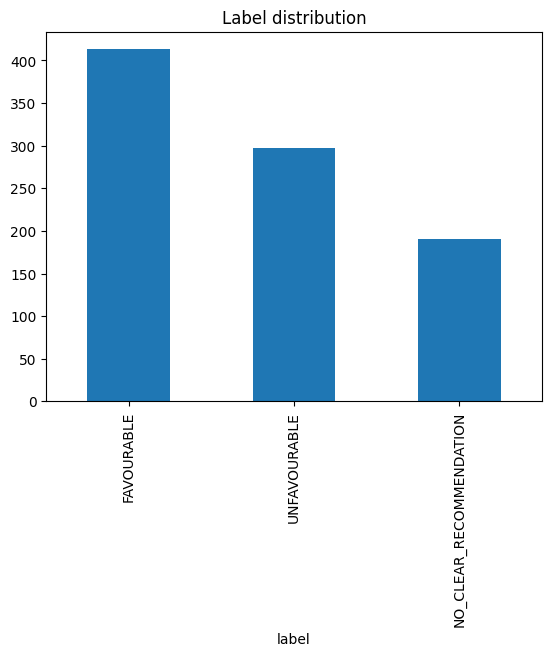

In [352]:
label_counts.plot(kind="bar", title="Label distribution")

### 2.4 Text statistics

The main textual fields in the dataset vary in length and completeness. Most entries contain short to medium-length text, with a small number of empty or very brief records. Text length statistics are reported to provide basic insight into the scale and variability of the textual input.

In [353]:
text_cols = ["grounds_clemency", "additional_info", "doc_description"]

for col in text_cols:
    lengths = df_train[col].fillna("").str.len()
    print(f"\n{col}")
    print(lengths.describe())


grounds_clemency
count    901.000000
mean     134.983352
std      152.109276
min        0.000000
25%        0.000000
50%       96.000000
75%      215.000000
max      948.000000
Name: grounds_clemency, dtype: float64

additional_info
count     901.000000
mean      236.762486
std       262.563193
min         0.000000
25%        68.000000
50%       156.000000
75%       313.000000
max      2160.000000
Name: additional_info, dtype: float64

doc_description
count    901.000000
mean     195.564928
std       96.742174
min       38.000000
25%      103.000000
50%      191.000000
75%      265.000000
max      651.000000
Name: doc_description, dtype: float64


<AxesSubplot:>

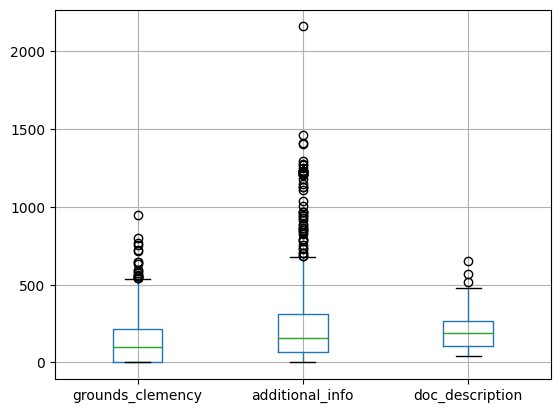

In [354]:
lengths_df = pd.DataFrame({
    col: df_train[col].fillna("").str.len()
    for col in text_cols
})

lengths_df.boxplot()

## 3. Evaluation

Model performance is evaluated using standard classification metrics. Given the class imbalance in the target variable, evaluation focuses on metrics that account for per-class performance rather than overall accuracy.

In [355]:
from sklearn.metrics import classification_report, f1_score

### 3.1 Metrics

Model performance is evaluated using the macro-averaged F1 score as the primary metric. Additional metrics, including per-class precision and recall, are reported for diagnostic purposes.

In [356]:
# True labels
y_true = df_train["label"]
majority_label = y_true.value_counts().idxmax()
y_pred = [majority_label] * len(y_true)

macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Majority label: {majority_label}")
print(f"Macro-F1 (majority baseline): {macro_f1:.4f}")

Majority label: FAVOURABLE
Macro-F1 (majority baseline): 0.2095


## 4. Modelling

This section describes the models used to address the classification task. A baseline model is first established, followed by progressively improved approaches.

In [357]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer

In [358]:
y_train = df_train["label"].values
y_test = df_test["label"].values

### 4.1 Baseline

A baseline classification model is used to establish a reference level of performance. The baseline uses only the `grounds_clemency` field as input, as it is the most directly related to the reasoning presented in support of clemency. The text is represented using TF–IDF features and classified with a logistic regression model with class-balanced weights.

In [359]:
BASELINE_TEXT_COL = "grounds_clemency"

In [360]:
baseline_single = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=10000
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

In [361]:
baseline_single.fit(df_train[BASELINE_TEXT_COL].fillna("").astype(str), y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(lowercase=False, max_df=0.95,
                                 max_features=10000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    n_jobs=-1, random_state=42))])

In [362]:
y_pred_base = baseline_single.predict(df_test[BASELINE_TEXT_COL].fillna("").astype(str))

In [363]:
print(classification_report(y_test, y_pred_base, digits=3))

baseline_single_macro_f1 = f1_score(y_test, y_pred_base, average="macro")
print(f"Baseline (single field) macro-F1: {baseline_single_macro_f1:.4f}")

                         precision    recall  f1-score   support

             FAVOURABLE      0.661     0.695     0.678       118
NO_CLEAR_RECOMMENDATION      0.391     0.220     0.281        41
           UNFAVOURABLE      0.519     0.612     0.562        67

               accuracy                          0.584       226
              macro avg      0.524     0.509     0.507       226
           weighted avg      0.570     0.584     0.571       226

Baseline (single field) macro-F1: 0.5069


### Baseline results

Using only the `grounds_clemency` field as input yields limited performance, with a macro-averaged F1 score of 0.507.

Performance is lowest for **NO_CLEAR_RECOMMENDATION** (F1: 0.281), indicating that this class cannot be reliably inferred from the stated grounds alone. Predictions for **FAVOURABLE** (F1: 0.678) and **UNFAVOURABLE** (F1: 0.562) are stronger but remain below the instructors’ solution.

This baseline establishes a minimal reference point and highlights the importance of incorporating broader contextual information beyond the grounds for clemency.

### 4.2 Instructors’ solution

The instructors’ solution extends the baseline by incorporating additional textual context beyond the stated grounds for clemency. Text from multiple fields is combined and represented using TF–IDF features, and a logistic regression classifier with class-balanced weights is used for prediction.

In [364]:
TEXT_COLUMNS = ["grounds_clemency", "additional_info", "doc_description"]

def merge_text_fields(df, text_cols):
    return (
        df[text_cols]
        .fillna("")
        .apply(lambda row: " ".join(t for t in row if t), axis=1)
        .str.strip()
    )

df_train["text"] = merge_text_fields(df_train, TEXT_COLUMNS)
df_test["text"] = merge_text_fields(df_test, TEXT_COLUMNS)
print(df_train["text"].str.len().describe())

count     901.000000
mean      568.891232
std       355.953151
min        64.000000
25%       281.000000
50%       510.000000
75%       749.000000
max      2703.000000
Name: text, dtype: float64


In [379]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=10000
    )),
    ("clf", LogisticRegression(
        C=2.0,
        max_iter=3000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

### 4.2 Training

Models are trained on the training split using the selected input features and labels. Hyperparameters are fixed, and training is performed with class-balanced weighting to account for label imbalance.

In [380]:
baseline.fit(df_train["text"], y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(lowercase=False, max_df=0.95,
                                 max_features=10000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf',
                 LogisticRegression(C=2.0, class_weight='balanced',
                                    max_iter=3000, n_jobs=-1,
                                    random_state=42))])

### 4.3 Prediction

Trained models are used to generate predictions on the held-out test set. Predicted labels are compared against the ground truth for evaluation.

In [381]:
y_pred = baseline.predict(df_test["text"])

### 4.4 Evaluation

Model performance is evaluated on the test set using the metrics defined in Section 3. Results are reported at both the overall and per-class levels.

In [382]:
print(classification_report(y_test, y_pred, digits=3))

baseline_macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Baseline macro-F1: {baseline_macro_f1:.4f}")

                         precision    recall  f1-score   support

             FAVOURABLE      0.867     0.720     0.787       118
NO_CLEAR_RECOMMENDATION      0.871     0.659     0.750        41
           UNFAVOURABLE      0.608     0.881     0.720        67

               accuracy                          0.757       226
              macro avg      0.782     0.753     0.752       226
           weighted avg      0.791     0.757     0.760       226

Baseline macro-F1: 0.7522


### Instructors’ solution results

- **Overall performance**
  - Macro-averaged F1: 0.752 (single-field baseline: 0.507)
- **Class-level comparison with the baseline**
  - **FAVOURABLE**: F1 increases from 0.678 to 0.787, with high precision (0.867)
  - **UNFAVOURABLE**: recall increases substantially, from 0.612 to 0.881 (F1: 0.720)
  - **NO_CLEAR_RECOMMENDATION**: performance improves markedly, reaching an F1 score of 0.750
- **Effect of additional textual inputs**
  - Incorporating multiple textual fields introduces procedural and contextual information absent from the grounds alone.
  - These fields provide implicit signals of judicial position that improve discrimination across all classes, particularly for ambiguous cases.
- **Remaining limitations**
  - Despite improvements, performance remains uneven across classes, reflecting differences in how explicitly judicial positions are expressed in the text.

Overall, the instructors’ solution demonstrates that combining broader textual context with a well-calibrated linear model substantially improves performance and is critical for modelling judicial recommendations in this dataset.

## 5. Analysis

This section examines model behaviour beyond aggregate performance metrics. Emphasis is placed on understanding systematic errors and class-specific patterns.

In [383]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### 5.1 Error analysis

Misclassified cases are examined to identify common sources of error. Particular attention is paid to confusions between adjacent or ambiguous classes.

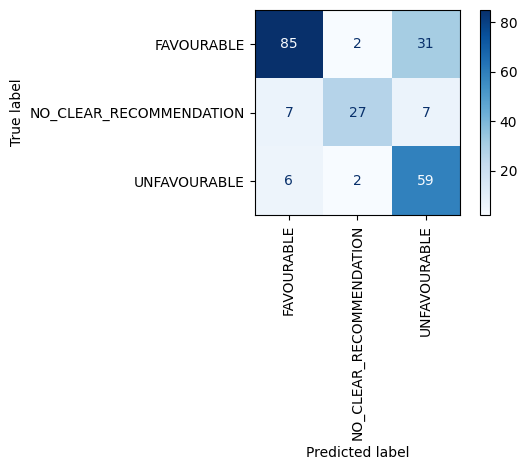

In [384]:
cm = confusion_matrix(y_test, y_pred, labels=baseline.classes_)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=baseline.classes_
)
disp.plot(cmap="Blues", xticks_rotation=90)
plt.tight_layout()
plt.show()

In [385]:
vectorizer = baseline.named_steps["tfidf"]
classifier = baseline.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = classifier.coef_
classes = classifier.classes_

In [386]:
def top_features_for_class(class_idx, top_k=20):
    coef = coefs[class_idx]
    top_idx = np.argsort(coef)[-top_k:][::-1]
    return pd.DataFrame({
        "ngram": feature_names[top_idx],
        "weight": coef[top_idx]
    })

for i, cls in enumerate(classes):
    print(f"\nTop features for class: {cls}")
    display(top_features_for_class(i, top_k=20))


Top features for class: FAVOURABLE


,ngram,weight
0,to serve,0.994021
1,serve,0.975524
2,free,0.906897
3,free pardon,0.855755
4,West,0.814750
5,transportation Report,0.774526
6,serve as,0.764515
7,in,0.756932
8,West Indies,0.745090
9,served,0.743520



Top features for class: NO_CLEAR_RECOMMENDATION


,ngram,weight
0,Petition,1.427042
1,Petition on,1.356958
2,from John,1.076626
3,is,0.995646
4,respited prisoners,0.965221
5,on respited,0.965221
6,transported,0.931065
7,recommendation,0.925103
8,behaviour for,0.911977
9,are,0.902328



Top features for class: UNFAVOURABLE


,ngram,weight
0,no mercy,1.836484
1,no,1.691695
2,mercy Report,1.684171
3,none given,1.620117
4,transportation no,1.546086
5,none,1.514209
6,mercy,1.247822
7,on petition,1.197435
8,petition on,1.126537
9,petition,1.004754


In [387]:
def ngram_length_distribution(class_idx, top_k=50):
    coef = coefs[class_idx]
    top_idx = np.argsort(coef)[-top_k:]
    ngrams = feature_names[top_idx]
    lengths = [len(ng.split()) for ng in ngrams]
    return pd.Series(lengths).value_counts().sort_index()

for i, cls in enumerate(classes):
    print(f"\nN-gram length distribution for class: {cls}")
    print(ngram_length_distribution(i, top_k=50))


N-gram length distribution for class: FAVOURABLE
1    23
2    27
Name: count, dtype: int64

N-gram length distribution for class: NO_CLEAR_RECOMMENDATION
1    28
2    22
Name: count, dtype: int64

N-gram length distribution for class: UNFAVOURABLE
1    27
2    23
Name: count, dtype: int64


In [388]:
def bigram_ratio(class_idx, top_k=50):
    coef = coefs[class_idx]
    top_idx = np.argsort(coef)[-top_k:]
    ngrams = feature_names[top_idx]
    return sum(len(ng.split()) == 2 for ng in ngrams) / top_k

for i, cls in enumerate(classes):
    ratio = bigram_ratio(i, top_k=50)
    print(f"{cls}: {ratio:.2%} bi-grams among top features")

FAVOURABLE: 54.00% bi-grams among top features
NO_CLEAR_RECOMMENDATION: 44.00% bi-grams among top features
UNFAVOURABLE: 46.00% bi-grams among top features


### Error analysis

Inspection of the most influential n-grams reveals distinct lexical patterns across classes.

- **FAVOURABLE**  
  High-weight features are dominated by terms related to mitigation and alternative punishments, including *serve*, *to serve*, *free*, *free pardon*, and references to *transportation* and overseas destinations such as *West Indies*. Many of these signals appear in short, formulaic constructions (e.g. *to serve*, *serve as*, *recommended to*). Among the top features, 58% are bi-grams, indicating that favourable recommendations are frequently expressed through multi-word constructions rather than isolated keywords.

- **NO_CLEAR_RECOMMENDATION**  
  The most influential features are procedural and administrative in nature, with high weights assigned to terms such as *petition*, *memorial*, *letter*, *respited*, *transported*, and references to correspondence or case status. These features describe document handling and procedural context rather than evaluative judgement. Bi-grams account for 44% of the top features, reflecting a mixed reliance on single-word and multi-word expressions.

- **UNFAVOURABLE**  
  Predictions are strongly driven by explicit negations of mercy, with *no mercy*, *none given*, *no*, and *none* among the highest-weight features. Negation-centred constructions such as *transportation no* and *mercy report* also play an important role. Bi-grams comprise 48% of the top features, consistent with direct and highly formulaic expressions of refusal.

Overall, the feature analysis indicates that the model relies on surface lexical cues. Classes associated with explicit evaluative language are more easily distinguished, while procedural or descriptive language contributes to ambiguity in cases with no clear recommendation.

In [389]:
X_test_tfidf = vectorizer.transform(df_test["text"])

def explain_instance(idx, top_k=10):
    x = X_test_tfidf[idx]
    true_label = y_true[idx]
    pred_label = y_pred[idx]

    pred_class_idx = np.where(classes == pred_label)[0][0]
    coef = coefs[pred_class_idx]

    contrib = x.multiply(coef).toarray().ravel()
    nz = x.nonzero()[1]
    contrib_nz = contrib[nz]

    top_pos_idx = nz[np.argsort(contrib_nz)[-top_k:][::-1]]
    top_neg_idx = nz[np.argsort(contrib_nz)[:top_k]]

    return {
        "true": true_label,
        "pred": pred_label,
        "supporting_ngrams": pd.DataFrame({
            "ngram": feature_names[top_pos_idx],
            "contribution": contrib[top_pos_idx]
        }),
        "opposing_ngrams": pd.DataFrame({
            "ngram": feature_names[top_neg_idx],
            "contribution": contrib[top_neg_idx]
        })
    }

In [390]:
mis_idx = np.where(y_test != y_pred)[0]
mis_sample = mis_idx[:5]

for idx in mis_sample:
    exp = explain_instance(idx, top_k=8)
    print(f"\nIndex: {idx} | True: {exp['true']} | Pred: {exp['pred']}")
    print("Text snippet:")
    print(df_test.iloc[idx]["text"][:400].replace("\n", " ") + "...")
    print("\nTop n-grams supporting the prediction:")
    display(exp["supporting_ngrams"])
    print("Top n-grams opposing the prediction:")
    display(exp["opposing_ngrams"])


Index: 9 | True: UNFAVOURABLE | Pred: UNFAVOURABLE
Text snippet:
youth (15 years), previous good character, first offence, and the detrimental effect it has had on her parents (her mother has since died).  There is also a letter from Sarah Herrold (prosecutor's wife) describing catching Margaret and the ensuing search of her clothing. They found a chisel and large keys such as are used for street doors in her pockets.  Report of James Adair, Recorder of London,...

Top n-grams supporting the prediction:


,ngram,contribution
0,wife,0.089448
1,Sarah,0.058030
2,on petition,0.056053
3,petition on,0.052914
4,11,0.050212
5,Edward,0.045739
6,petition,0.043582
7,keys,0.043328


Top n-grams opposing the prediction:


,ngram,contribution
0,and the,-0.046357
1,such,-0.039497
2,of her,-0.034685
3,since,-0.032483
4,is also,-0.031570
5,1787,-0.031140
6,youth,-0.030229
7,has since,-0.029189



Index: 13 | True: FAVOURABLE | Pred: UNFAVOURABLE
Text snippet:
first offence, is truly sorry, petitioner (Hearne) 'is much concerned at the heavy Punishment' and was a reliable worker.  Evidences supplied by Abraham Hearne, the prisoner's employer and the prisoner.  Report of John William Rose, Recorder of London, on a  petition  on behalf of William Blackett, convicted at the Old Bailey in December 1792, for stealing a horse collar, bridle and other equipmen...

Top n-grams supporting the prediction:


...

,ngram,contribution
0,1786,-0.065689
1,served,-0.062467
2,already served,-0.061051
3,1786 for,-0.046605
4,with James,-0.030802
5,years and,-0.029280
6,already,-0.028600
7,served years,-0.028146



Index: 20 | True: NO_CLEAR_RECOMMENDATION | Pred: UNFAVOURABLE
Text snippet:
is sensible of his crime and for service done to the public in informing Alderman Skinner on 2 fellow prisoners in Newgate Gaol (Lowe and Jobbins, convicted for arson on a property at Aldersgate Street (with ------ Flindell) who were subsequently executed.  The judge refers to another earlier favourable report on behalf of the prisoner.  Report of John William Rose, Recorder of London, on a  petit...

Top n-grams supporting the prediction:


,ngram,contribution
0,convicted for,0.074656
1,value,0.067455
2,The judge,0.059618
3,on petition,0.058232
4,petition on,0.054971
5,petition,0.045276
6,The,0.044836
7,on behalf,0.039144


Top n-grams opposing the prediction:


,ngram,contribution
0,crime,-0.049947
1,crime and,-0.035766
2,in Newgate,-0.033934
3,report,-0.033689
4,Newgate,-0.031815
5,Skinner,-0.030155
6,1789 for,-0.023764
7,public,-0.018747


### Case-level error analysis

Inspection of individual predictions reveals consistent patterns in how errors arise.

- **Procedural dominance in misclassifications**  
  Several misclassified cases contain strong procedural signals, particularly repeated references to *petition*, *on petition*, and *report*. These cues frequently push predictions toward **UNFAVOURABLE**, even when the true label is **FAVOURABLE** or **NO_CLEAR_RECOMMENDATION**. This reflects the strong association between petition-related language and refusal learned by the model.

- **Mitigation expressed without explicit recommendation**  
  Some **FAVOURABLE** cases are misclassified when mitigating factors such as youth, remorse, prior good character, or hardship are described narratively but not paired with explicit phrases indicating mercy. In these cases, implicit mitigation is outweighed by procedural or evidentiary language.

- **Correct predictions driven by explicit markers**  
  Correct **FAVOURABLE** predictions are typically supported by explicit lexical cues such as *free pardon* or references to exemption from transportation. Similarly, correct **UNFAVOURABLE** predictions rely on direct negations of mercy or formulaic refusals.

- **Ambiguity in NO_CLEAR_RECOMMENDATION cases**  
  Cases labelled **NO_CLEAR_RECOMMENDATION** often combine procedural detail with limited evaluative language. When neither explicit mercy nor refusal is present, predictions become sensitive to surface cues, leading to unstable or default classifications.

Overall, the case-level analysis confirms that errors arise not from model instability but from the interaction between implicit mitigation signals and strong procedural language in the source documents.

## 6. Alternative Solution

This section explores alternative modelling approaches aimed at improving performance over the baseline. Improvements focus on feature representation and model architecture.

In [391]:
from sklearn.svm import LinearSVC
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

### 6.1 Latent Semantic Analysis (TF–IDF + SVD)

In [396]:
lsa = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=10000
    )),
    ("svd", TruncatedSVD(n_components=300, random_state=42)),
    ("norm", Normalizer(copy=False)),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

#### 6.1.1 Training

In [397]:
lsa.fit(df_train["text"], y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(lowercase=False, max_df=0.95,
                                 max_features=10000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('svd', TruncatedSVD(n_components=300, random_state=42)),
                ('norm', Normalizer(copy=False)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    n_jobs=-1, random_state=42))])

#### 6.1.2 Prediction

In [398]:
y_pred_lsa = lsa.predict(df_test["text"])

#### 6.1.3 Evaluation

In [399]:
print(classification_report(y_test, y_pred_lsa, digits=3))

lsa_macro_f1 = f1_score(y_test, y_pred_lsa, average="macro")
print(f"LSA macro-F1: {lsa_macro_f1:.4f}")

                         precision    recall  f1-score   support

             FAVOURABLE      0.912     0.619     0.737       118
NO_CLEAR_RECOMMENDATION      0.839     0.634     0.722        41
           UNFAVOURABLE      0.539     0.925     0.681        67

               accuracy                          0.712       226
              macro avg      0.763     0.726     0.714       226
           weighted avg      0.788     0.712     0.718       226

LSA macro-F1: 0.7136


### LSA results

The LSA model achieves slightly lower overall performance than the instructors’ solution, with a macro-averaged F1 score of 0.714.

Performance is strongest for **FAVOURABLE** (F1: 0.737) and **NO_CLEAR_RECOMMENDATION** (F1: 0.722). In contrast, performance for **UNFAVOURABLE** decreases (F1: 0.681), reflecting reduced sensitivity to explicit lexical cues after dimensionality reduction.

Overall, applying TruncatedSVD does not improve macro-F1 in this setting and slightly degrades performance relative to the sparse TF–IDF representation.

### 6.2 Sentence embeddings + Logistic Regression

In [400]:
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

/opt/homebrew/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [401]:
X_train_text = df_train["text"].fillna("").astype(str).tolist()
X_test_text = df_test["text"].fillna("").astype(str).tolist()

X_train_emb = embedder.encode(
    X_train_text, 
    batch_size=64, 
    show_progress_bar=True, 
    normalize_embeddings=True
)

X_test_emb = embedder.encode(
    X_test_text, 
    batch_size=64, 
    show_progress_bar=True, 
    normalize_embeddings=True
)

X_train_emb.shape, X_test_emb.shape

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

((901, 768), (226, 768))

#### 6.2.1 Training

In [406]:
emb_clf = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

emb_clf.fit(X_train_emb, y_train)

LogisticRegression(class_weight='balanced', max_iter=3000, n_jobs=-1,
                   random_state=42)

#### 6.2.2 Prediction

In [407]:
y_pred_emb = emb_clf.predict(X_test_emb)

#### 6.2.3 Evaluation

In [408]:
print(classification_report(y_test, y_pred_emb, digits=3))

emb_macro_f1 = f1_score(y_test, y_pred_emb, average="macro")
print(f"Embeddings macro-F1: {emb_macro_f1:.4f}")

                         precision    recall  f1-score   support

             FAVOURABLE      0.779     0.627     0.695       118
NO_CLEAR_RECOMMENDATION      0.511     0.585     0.545        41
           UNFAVOURABLE      0.560     0.701     0.623        67

               accuracy                          0.642       226
              macro avg      0.616     0.638     0.621       226
           weighted avg      0.665     0.642     0.646       226

Embeddings macro-F1: 0.6209


### Sentence embeddings + LR results

The sentence embedding model based on *all-mpnet-base-v2* underperforms the sparse TF–IDF-based models, achieving a macro-averaged F1 score of 0.621.

Performance degrades across all classes, with the largest reduction observed for **NO_CLEAR_RECOMMENDATION** (F1: 0.545). While precision and recall are relatively balanced, they remain substantially lower than those obtained with n-gram representations.

These results indicate that dense sentence embeddings, while effective for capturing semantic similarity, are less suited to this task. Predicting judicial position relies heavily on specific lexical cues and formulaic expressions, which are preserved more effectively by sparse representations than by distributed embeddings.

### 6.3 Sentence embeddings + Support Vector Machine (SVM)

In [156]:
from sklearn.svm import LinearSVC
emb_svm = LinearSVC(class_weight="balanced", random_state=42)

#### 6.3.1 Training

In [157]:
emb_svm.fit(X_train_emb, y_train)

LinearSVC(class_weight='balanced', random_state=42)

#### 6.3.2 Prediction

In [158]:
y_pred_emb_svm = emb_svm.predict(X_test_emb)

#### 6.3.3 Evaluation

In [159]:
print(classification_report(y_test, y_pred_emb_svm, digits=3))
print("Embeddings (LinearSVC) macro-F1:", f1_score(y_test, y_pred_emb_svm, average="macro"))

                         precision    recall  f1-score   support

             FAVOURABLE      0.778     0.653     0.710       118
NO_CLEAR_RECOMMENDATION      0.556     0.610     0.581        41
           UNFAVOURABLE      0.598     0.731     0.658        67

               accuracy                          0.668       226
              macro avg      0.644     0.665     0.650       226
           weighted avg      0.684     0.668     0.671       226

Embeddings (LinearSVC) macro-F1: 0.649596962999139


### Sentence embeddings + SVM results

Using sentence embeddings with a linear SVM improves performance over logistic regression on embeddings but remains below the TF–IDF-based models.

The macro-averaged F1 score reaches 0.650. Performance is strongest for **FAVOURABLE** cases (F1: 0.710), while **NO_CLEAR_RECOMMENDATION** remains challenging (F1: 0.581), reflecting continued difficulty in modelling ambiguous or procedural cases.

Overall, while a linear SVM better exploits dense representations than logistic regression, sentence embeddings still underperform sparse n-gram features for this task. This further indicates that explicit lexical and formulaic cues play a central role in predicting judicial position in this dataset.